In [1]:
import numpy as np
from matplotlib import pyplot as plt

In [2]:
from scipy.integrate import solve_bvp

In [3]:
solve_bvp?

Signature:
solve_bvp(
    fun,
    bc,
    x,
    y,
    p=None,
    S=None,
    fun_jac=None,
    bc_jac=None,
    tol=0.001,
    max_nodes=1000,
    verbose=0,
    bc_tol=None,
)
Docstring:
Solve a boundary value problem for a system of ODEs.

This function numerically solves a first order system of ODEs subject to
two-point boundary conditions::

    dy / dx = f(x, y, p) + S * y / (x - a), a <= x <= b
    bc(y(a), y(b), p) = 0

Here x is a 1-D independent variable, y(x) is an N-D
vector-valued function and p is a k-D vector of unknown
parameters which is to be found along with y(x). For the problem to be
determined, there must be n + k boundary conditions, i.e., bc must be an
(n + k)-D function.

The last singular term on the right-hand side of the system is optional.
It is defined by an n-by-n matrix S, such that the solution must satisfy
S y(a) = 0. This condition will be forced during iterations, so it must not
contradict boundary conditions. See [2]_ for the explanation how this

In [30]:
def fun(t, y):
    u, v = y[0], y[1]
    return np.vstack((v, (1-t/5)*u + t))

def bc(ya, yb):
    return np.array([ya[0]-2, yb[0]+1])

In [45]:
x = np.linspace(1, 3, 100) #mesh with 5 nodes

y_a = np.zeros((2, x.size))
y_b = np.zeros((2, x.size))
#y_a[0] = 2
#y_b[0] = -1
y_a, y_b


(array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0.]]),
 array([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0

In [46]:
res_a = solve_bvp(fun, bc, x, y_a)
res_b = solve_bvp(fun, bc, x, y_b)

In [47]:
res_a['y']

array([[ 2.00000000e+00,  1.92992180e+00,  1.86088694e+00,
         1.79287818e+00,  1.72587883e+00,  1.65987273e+00,
         1.59484427e+00,  1.53077839e+00,  1.46766051e+00,
         1.40547657e+00,  1.34421303e+00,  1.28385682e+00,
         1.22439535e+00,  1.16581651e+00,  1.10810866e+00,
         1.05126061e+00,  9.95261625e-01,  9.40101405e-01,
         8.85770094e-01,  8.32258257e-01,  7.79556884e-01,
         7.27657378e-01,  6.76551550e-01,  6.26231613e-01,
         5.76690174e-01,  5.27920231e-01,  4.79915165e-01,
         4.32668733e-01,  3.86175068e-01,  3.40428665e-01,
         2.95424385e-01,  2.51157443e-01,  2.07623407e-01,
         1.64818189e-01,  1.22738047e-01,  8.13795717e-02,
         4.07396899e-02,  8.15655479e-04, -3.83949536e-02,
        -7.68942392e-02, -1.14683987e-01, -1.51765673e-01,
        -1.88140462e-01, -2.23809216e-01, -2.58772498e-01,
        -2.93030572e-01, -3.26583411e-01, -3.59430696e-01,
        -3.91571822e-01, -4.23005904e-01, -4.53731773e-0

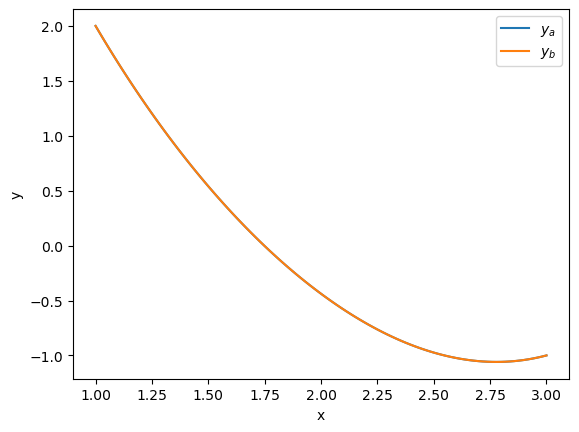

In [48]:
x_plot = np.linspace(1, 3, 100)
y_plot_a = res_a.sol(x_plot)[0]
y_plot_b = res_b.sol(x_plot)[0]

plt.plot(x_plot, y_plot_a, label=r'$y_a$')
plt.plot(x_plot, y_plot_b, label=r'$y_b$')
plt.legend()
plt.xlabel("x")
plt.ylabel("y")
plt.show()